# Answers to Comments 3

In [124]:
## the data are 1mm thin slices. How does this method work on thick slice data (>3mm).

## imports

In [70]:
# libraries
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# custom
from data_2D_utilities import *
from data_3D_utilities import *
from Dense_Unet_Centroid import *
from result_2D_utilities import *

## Path Setting

In [171]:
#Windows
#rootPath = "E:/Dataset from SpineWeb/Dataset2-Jack"
#Linux
rootPath = '/home/shu/Dataset/TestHealthyCases/Resample9'
SrcmhdFolder = '/Resample1' #'/Resample'

## 数据重采样

In [102]:
#获得cases和labels所在的文件所有路径
cases = sorted(glob(rootPath + '/Source/images/*.mhd'))#[0:1]
labels = sorted(glob(rootPath + '/Source/masks/*.mhd'))#[0:1]
Denses = sorted(glob(rootPath + '/Source/Dense/*.mhd'))#[0:1]
cases,labels,Denses

(['/home/shu/Dataset/TestHealthyCases/Resample9/Source/images/Resmpl_case18.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/images/Resmpl_case19.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/images/Resmpl_case20.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/images/Resmpl_case22.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/images/Resmpl_case23.mhd'],
 ['/home/shu/Dataset/TestHealthyCases/Resample9/Source/masks/Resmpl_case18_label.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/masks/Resmpl_case19_label.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/masks/Resmpl_case20_label.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/masks/Resmpl_case22_label.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/masks/Resmpl_case23_label.mhd'],
 ['/home/shu/Dataset/TestHealthyCases/Resample9/Source/Dense/Resmpl_case018_Dense.mhd',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Source/Dense/Resm

In [103]:
# 重采样到1x1x4～9
newspacing = np.array([1,1,1])

for mhd in cases:
    filename = os.path.split(mhd)[1]
    resamplefile = rootPath + SrcmhdFolder + '/images/Resmpl_' + filename
    newimg = ImageResample(mhd,resamplefile,newspacing,False)
    
for mhd in labels:    
    filename = os.path.split(mhd)[1]
    resamplefile = rootPath + SrcmhdFolder + '/masks/Resmpl_' + filename
    newimg = ImageResample(mhd,resamplefile,newspacing,True)

for mhd in Denses:    
    filename = os.path.split(mhd)[1]
    resamplefile = rootPath + SrcmhdFolder + '/Dense/Resmpl_' + filename
    newimg = ImageResample(mhd,resamplefile,newspacing,False)

# 2D-Dense-U-Net 结果评价

## 2D-Dense-U-Net的Input

In [104]:
# 从重采样或截取标注对应范围后的数据集生成2D-Dense-U-Net网络的输入
# 生成连续的128*128的png文件

input_cases = sorted(glob(rootPath + SrcmhdFolder + '/images/*.mhd'))#[0:1]
print(input_cases)
i = 0
for case in input_cases:
    filename = re.sub(r'.mhd', '',os.path.split(case)[1])
    out = rootPath + SrcmhdFolder + '/images128/' + filename
    mhd2pngR(case,out,False,128,128,0,4095)
    i = i + 1

['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images/Resmpl_Resmpl_case18.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images/Resmpl_Resmpl_case19.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images/Resmpl_Resmpl_case20.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images/Resmpl_Resmpl_case22.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images/Resmpl_Resmpl_case23.mhd']


In [105]:
# 将2k+1个png文件组成一个对应的bin文件，作为2D-Dense-U-Net的输入

png128s = sorted(glob(rootPath + SrcmhdFolder + '/images128/*/*.png'))
for png in png128s:
    imggroup = read_png2bin(png,4)

## 2D-Dense-U-Net的Output

In [106]:
# 生成连续的128*128的Dense的png文件
Dense_cases = sorted(glob(rootPath + SrcmhdFolder + '/Dense/*.mhd'))#[0:1]
print(Dense_cases)
i = 0
for Dense in Dense_cases:
    filename = re.sub(r'.mhd', '',os.path.split(Dense)[1])
    out = rootPath + SrcmhdFolder + '/Dense128/' + filename
    mhd2pngCZEnhance(Dense,out,False,128,128)
    i = i + 1

['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense/Resmpl_Resmpl_case018_Dense.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense/Resmpl_Resmpl_case019_Dense.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense/Resmpl_Resmpl_case020_Dense.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense/Resmpl_Resmpl_case022_Dense.mhd', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense/Resmpl_Resmpl_case023_Dense.mhd']
45
44
47
45
43


## predict

In [107]:
# 设置用于训练的GPU
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
# The GPU id to use, usually either "0" or "1"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [108]:
test_cases_folders = sorted(os.listdir(rootPath + SrcmhdFolder + '/images128/'))#[0:1]
test_labels_folders = sorted(os.listdir(rootPath + SrcmhdFolder + '/Dense128/'))#[0:1]

In [109]:
test_cases_folders,test_labels_folders

(['Resmpl_Resmpl_case18',
  'Resmpl_Resmpl_case19',
  'Resmpl_Resmpl_case20',
  'Resmpl_Resmpl_case22',
  'Resmpl_Resmpl_case23'],
 ['Resmpl_Resmpl_case018_Dense',
  'Resmpl_Resmpl_case019_Dense',
  'Resmpl_Resmpl_case020_Dense',
  'Resmpl_Resmpl_case022_Dense',
  'Resmpl_Resmpl_case023_Dense'])

In [110]:
# 2D-Dense-Unet-Centroid-20210918-180412 depth:17
# 2D-Dense-Unet-Centroid-20210919-160627 depth:25

In [111]:
# 依次加载测试数据集并预测
img_rows = 128
img_cols = 128
i = 0
for testfile in test_cases_folders:
    casesPath = rootPath + SrcmhdFolder + '/images128/' + testfile + '/*.bin'
    labelsPath = rootPath + SrcmhdFolder + '/Dense128/' + test_labels_folders[i] + '/*.png'
    # print(casesPath,labelsPath)
    dataset_test = dataset_test_build(casesPath,labelsPath)

    # 预测测试结果
    weight_dir = os.path.join('weights', '2D-Dense-Unet-Centroid-20210414-232724' + '.h5')
    outPath = rootPath + SrcmhdFolder + "/pred_Dense128/" + "pred_" + testfile + "/"
    predict_2D(weight_dir,dataset_test,outPath)
    i = i + 1

['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case18/537.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case18/538.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case18/539.bin'] ['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case018_Dense/537.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case018_Dense/538.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case018_Dense/539.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 28ms/step


1/1 [==============================] - 0s 21ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case19/609.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case19/610.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case19/611.bin'] ['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case019_Dense/609.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case019_Dense/610.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case019_Dense/611.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 20ms/step


1/1 [==============================] - 0s 24ms/step


1/1 [==============================] - 0s 20ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case20/528.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case20/529.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case20/530.bin'] ['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case020_Dense/528.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case020_Dense/529.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case020_Dense/530.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 25ms/step


1/1 [==============================] - 0s 27ms/step


1/1 [==============================] - 0s 22ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case22/546.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case22/547.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case22/548.bin'] ['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case022_Dense/546.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case022_Dense/547.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case022_Dense/548.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 24ms/step


1/1 [==============================] - 0s 30ms/step


1/1 [==============================] - 0s 38ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case23/645.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case23/646.bin', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/images128/Resmpl_Resmpl_case23/647.bin'] ['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case023_Dense/645.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case023_Dense/646.png', '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Dense128/Resmpl_Resmpl_case023_Dense/647.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - ETA:  - 0s 26ms/step


1/1 [==============================] - 0s 22ms/step


1/1 [==============================] - 0s 28ms/step
------------------------------
Prediction finished
------------------------------


## Get predicted centroids

In [125]:
pred_DensePath = rootPath + SrcmhdFolder + '/pred_Dense128/'# /Dense128/test/'

# pred_DensePath = '/home/shu/Dataset/Dataset2-Jack' + '/pred_Dense/'

In [126]:
pred_Dense_folders = sorted(os.listdir(pred_DensePath))#[4:5]

In [127]:
pred_Dense_folders

['pred_Resmpl_Resmpl_case18',
 'pred_Resmpl_Resmpl_case19',
 'pred_Resmpl_Resmpl_case20',
 'pred_Resmpl_Resmpl_case22',
 'pred_Resmpl_Resmpl_case23']

[ 99.42857143 145.57142857 158.71428571 146.85714286 164.85714286
 168.28571429 174.         164.85714286 165.57142857 175.42857143
 175.71428571 174.14285714 173.14285714 173.85714286 175.42857143
 168.14285714 187.42857143 201.28571429]
[ 18  34  50  70  89 109 130 151 173 196 219 243 269 300 329 361 392 424]


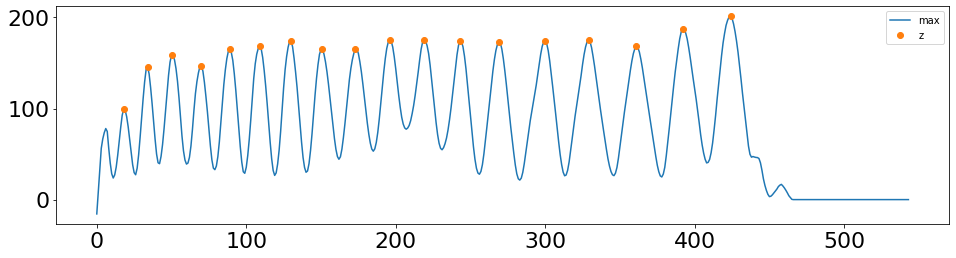

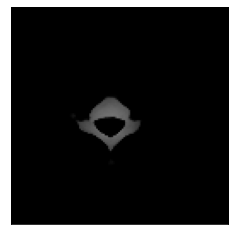

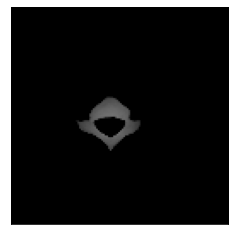

20 114


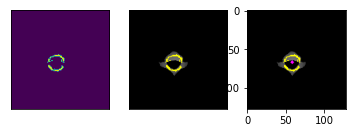

20 114


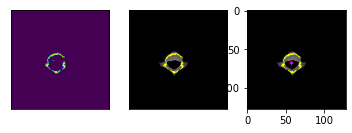

20 114


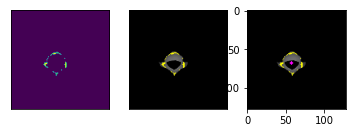

20 114


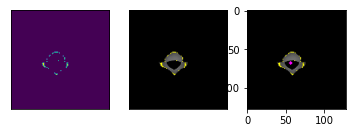

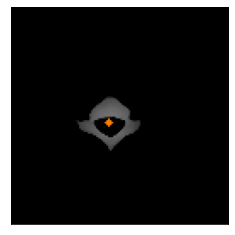

20 159
20 159
20 159
20 159
20 167
20 167
20 167
20 167
20 152
20 152
20 152
20 152
20 177
20 177
20 177
20 177
20 179
20 179
20 179
20 179
20 179
20 179
20 179
20 179
21 177
21 177
21 177
21 177
20 174
20 174
20 174
20 174
20 190
20 190
20 190
20 190
20 188
20 188
20 188
20 188
20 186
20 186
20 186
20 186
20 186
20 186
20 186
20 186
21 190
21 190
21 190
21 190
20 188
20 188
20 188
20 188
20 182
20 182
20 182
20 182
20 200
20 200
20 200
20 200
20 213
20 213
20 213
20 213
18
[135.42857143 137.14285714 179.14285714 177.         181.71428571
 181.28571429 183.28571429 186.14285714 182.28571429 176.14285714
 182.         180.85714286 159.14285714 180.42857143 189.
 204.85714286 193.85714286 181.71428571]
[ 17  35  53  74  96 119 145 169 194 220 248 278 310 343 379 417 454 489]


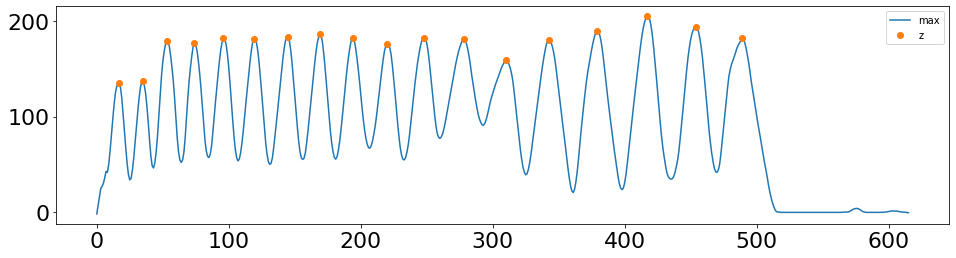

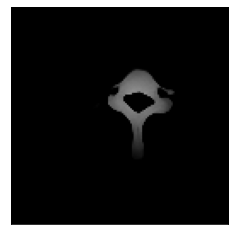

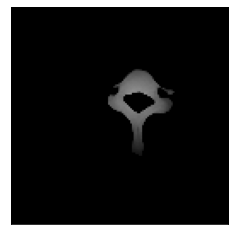

20 147


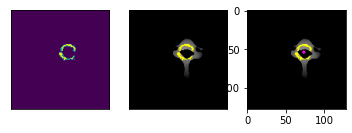

20 147


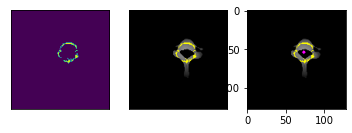

20 147


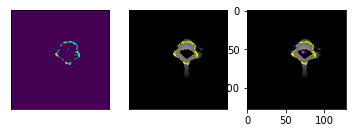

20 147


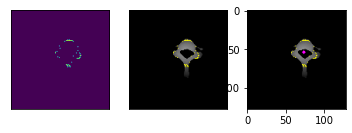

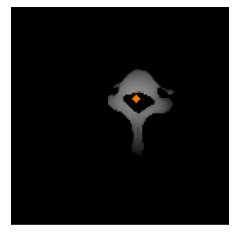

20 152
20 152
20 152
20 152
20 189
20 189
20 189
20 189
20 186
20 186
20 186
20 186
20 192
20 192
20 192
20 192
20 195
20 195
20 195
20 195
20 197
20 197
20 197
20 197
21 201
21 201
21 201
21 201
20 190
20 190
20 190
20 190
20 183
20 183
20 183
20 183
20 189
20 189
20 189
20 189
20 183
20 183
20 183
20 183
20 158
20 158
20 158
20 158
20 184
20 184
20 184
20 184
21 196
21 196
21 196
21 196
20 210
20 210
20 210
20 210
20 195
20 195
20 195
20 195
20 189
20 189
20 189
20 189
18
[125.         160.         172.57142857 164.         168.14285714
 170.85714286 175.42857143 184.28571429 180.28571429 181.57142857
 188.         174.28571429 169.         176.57142857 185.
 187.42857143 180.42857143  93.42857143]
[ 11  29  46  67  87 109 132 157 182 207 234 262 292 324 357 391 425 449]


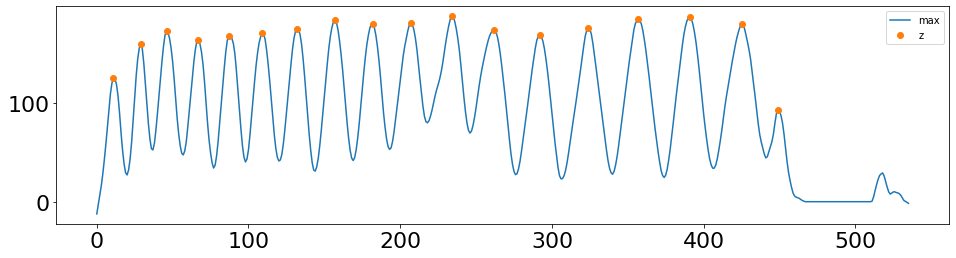

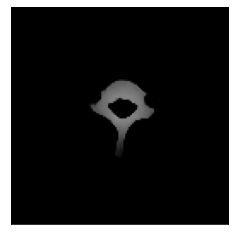

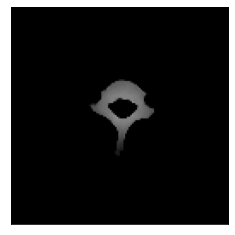

20 140


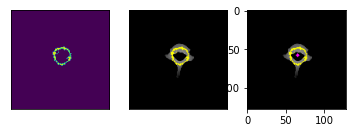

20 140


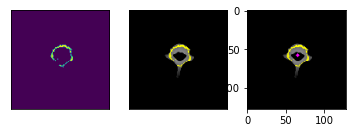

20 140


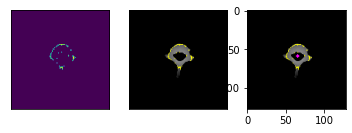

20 140


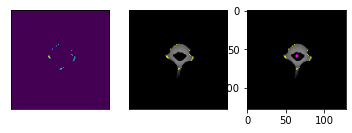

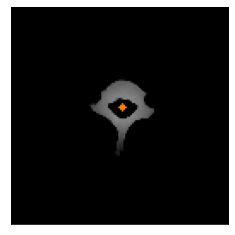

20 185
20 185
20 185
20 185
20 179
20 179
20 179
20 179
21 176
21 176
21 176
21 176
20 173
20 173
20 173
20 173
20 178
20 178
20 178
20 178
22 191
22 191
22 191
22 191
20 191
20 191
20 191
20 191
21 184
21 184
21 184
21 184
21 186
21 186
21 186
21 186
22 193
22 193
22 193
22 193
21 182
21 182
21 182
21 182
20 178
20 178
20 178
20 178
22 194
22 194
22 194
22 194
20 195
20 195
20 195
20 195
20 192
20 192
20 192
20 192
20 186
20 186
20 186
20 186
20 104
20 104
20 104
20 104
18
[146.71428571 152.57142857 165.28571429 174.14285714 168.42857143
 166.14285714 175.14285714 185.         200.42857143 190.28571429
 200.14285714 195.28571429 181.28571429 183.         188.85714286
 193.14285714 188.28571429 200.85714286]
[ 17  32  53  72  92 112 134 157 180 204 227 254 281 311 341 373 406 437]


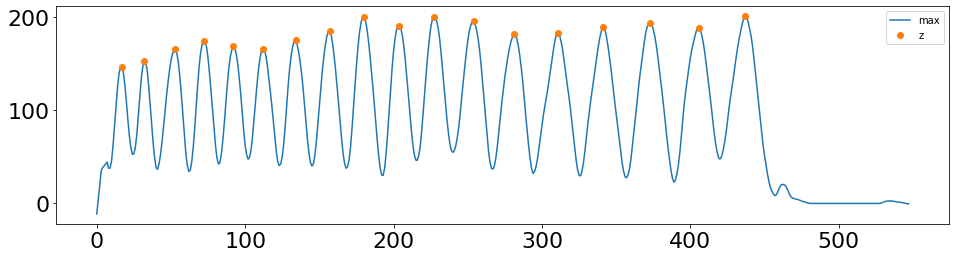

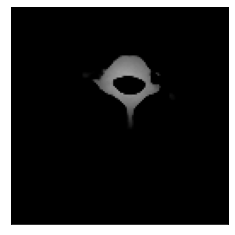

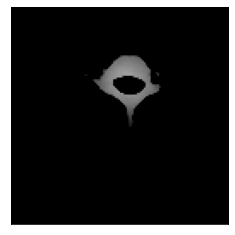

20 161


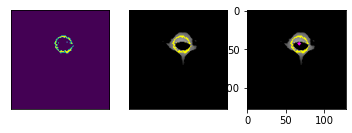

20 161


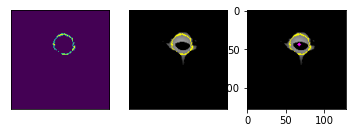

20 161


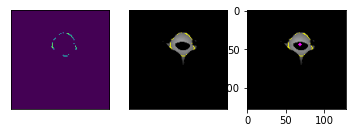

20 161


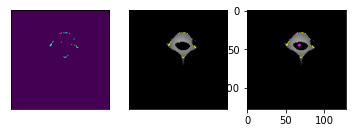

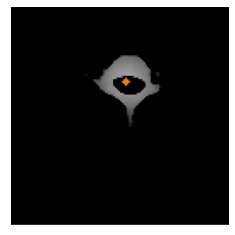

20 180
20 180
20 180
20 180
20 180
20 180
20 180
20 180
21 194
21 194
21 194
21 194
20 181
20 181
20 181
20 181
20 181
20 181
20 181
20 181
20 181
20 181
20 181
20 181
20 194
20 194
20 194
20 194
21 212
21 212
21 212
21 212
21 200
21 200
21 200
21 200
20 206
20 206
20 206
20 206
20 200
20 200
20 200
20 200
20 190
20 190
20 190
20 190
20 198
20 198
20 198
20 198
20 200
20 200
20 200
20 200
20 205
20 205
20 205
20 205
20 198
20 198
20 198
20 198
20 204
20 204
20 204
20 204
18
[133.         172.71428571 171.         164.71428571 177.42857143
 183.85714286 188.42857143 200.28571429 193.         203.42857143
 190.71428571 200.14285714 181.28571429 184.14285714 177.57142857
 196.         193.57142857]
[ 16  35  55  75  95 117 139 162 185 212 239 267 298 330 363 395 425]


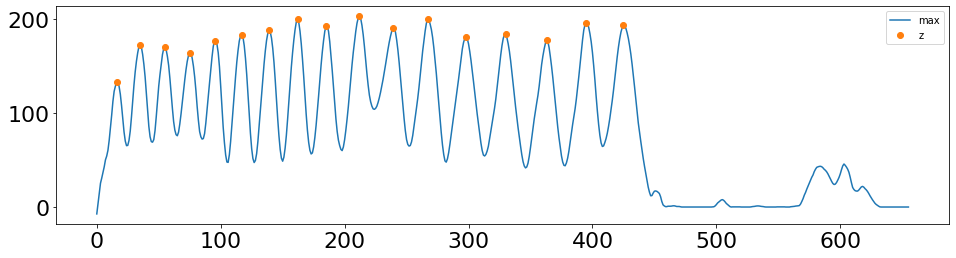

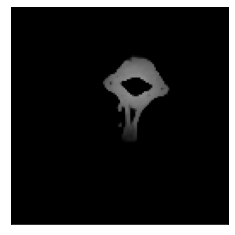

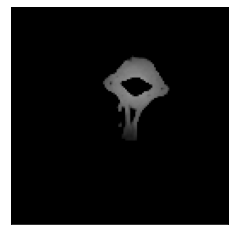

20 144


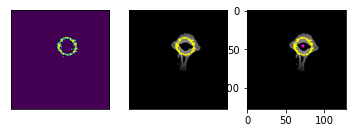

20 144


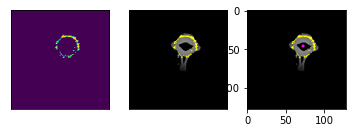

20 144


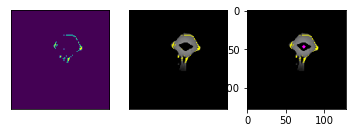

20 144


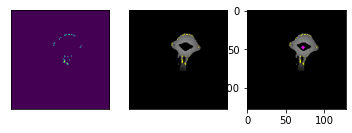

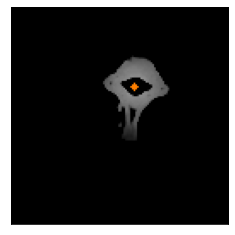

20 180
20 180
20 180
20 180
21 180
21 180
21 180
21 180
20 175
20 175
20 175
20 175
20 191
20 191
20 191
20 191
23 196
23 196
23 196
23 196
20 203
20 203
20 203
20 203
20 209
20 209
20 209
20 209
20 204
20 204
20 204
20 204
20 214
20 214
20 214
20 214
20 195
20 195
20 195
20 195
20 200
20 200
20 200
20 200
20 191
20 191
20 191
20 191
20 191
20 191
20 191
20 191
20 182
20 182
20 182
20 182
20 204
20 204
20 204
20 204
20 198
20 198
20 198
20 198
17


In [128]:
# 得到泛化能力测试的中心点坐标
i = 0
for pred_Dense in pred_Dense_folders:
    
    imagePath = rootPath + SrcmhdFolder + '/images/' + re.sub(r'pred_','',pred_Dense_folders[i]) + '.mhd'
    predsPath = pred_DensePath + pred_Dense + '/*.png'
    IJKPath = rootPath + SrcmhdFolder + "/pred_Centroids128/IJKpred/" + pred_Dense + '.csv'
    lenCentroids = GetCentroids(predsPath,IJKPath,imagePath,20)
    print(lenCentroids)
    i+=1

## Eval LE of Centroids

In [172]:
Centroids = sorted(glob(rootPath + SrcmhdFolder + '/Centroids/IJK/*.csv'))#[10:]
Pred_Centroids = sorted(glob(rootPath + SrcmhdFolder + '/pred_Centroids128/IJKpred/*.csv'))#[0:1]

In [173]:
Centroids,Pred_Centroids

(['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Centroids/IJK/Resmpl_Resmpl_case18_label.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Centroids/IJK/Resmpl_Resmpl_case19_label.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Centroids/IJK/Resmpl_Resmpl_case20_label.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Centroids/IJK/Resmpl_Resmpl_case22_label.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/Centroids/IJK/Resmpl_Resmpl_case23_label.csv'],
 ['/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/pred_Centroids128/IJKpred/pred_Resmpl_Resmpl_case18.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/pred_Centroids128/IJKpred/pred_Resmpl_Resmpl_case19.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/pred_Centroids128/IJKpred/pred_Resmpl_Resmpl_case20.csv',
  '/home/shu/Dataset/TestHealthyCases/Resample9/Resample1/pred_Centroids128/IJKpred/pred_Resmpl_Resmpl_case22.csv',
  '/home/s

In [177]:
LE_lists,mean_lists,std_lists,mean_LEs,std_LEs = GetLE(Centroids,Pred_Centroids)

In [178]:
mean_lists

[2.306624949574228,
 2.9901633213521865,
 2.9869809550077817,
 2.2140852741018517,
 2.465653408411459]

In [179]:
mean_LEs,std_LEs

(2.5927015816895014, 0.271762559177069)